<a href="https://colab.research.google.com/github/irfan-ardiansyah/data-science-2026/blob/main/Pertemuan_5_Muhammad_Irfan_Ardiansyah_250401020175.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [193]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('tips') # ganti sesuai pilihan
print(df.shape, df.dtypes)
print(df.describe().round(2))


(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


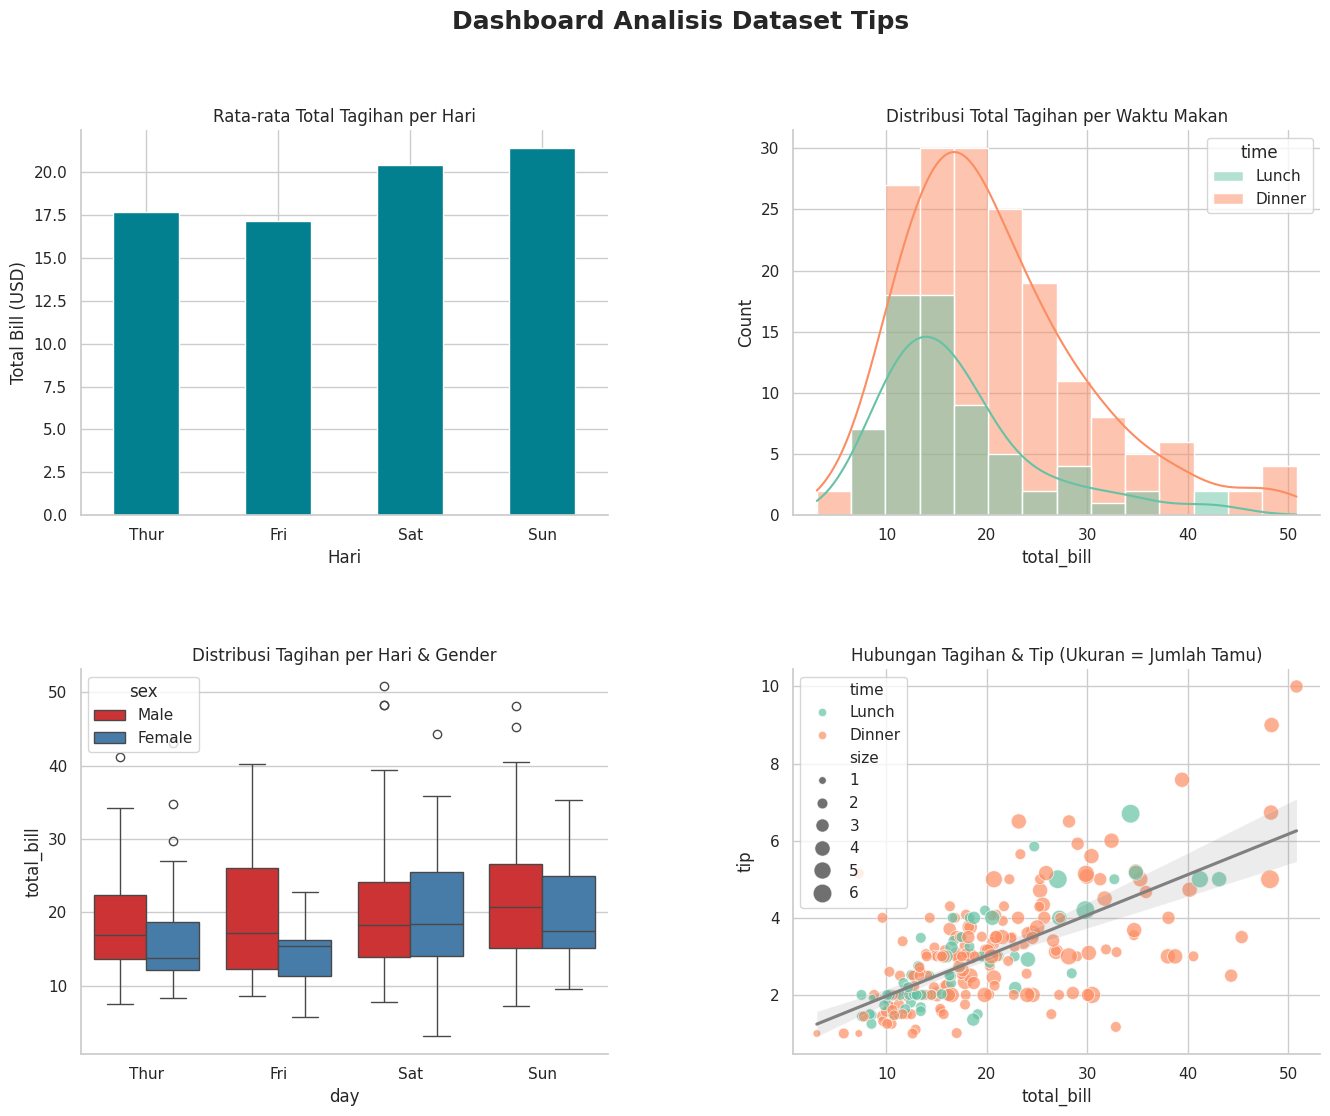

Dashboard tersimpan sebagai dashboard_tips.png


In [194]:

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips', fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
# kiri atas
# kanan atas
# kiri bawah
# kanan bawah

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')

ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari'); ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='day', y='total_bill',hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip',
scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')


# Insight Grafik 1 — Bar Chart

## What?
Grafik bar menunjukkan rata-rata total tagihan pelanggan restoran untuk setiap hari. Hari Minggu memiliki rata-rata total bill tertinggi sekitar 21 USD, sedangkan Jumat memiliki rata-rata paling rendah sekitar 17 USD.

## So what?
Hal ini menunjukkan bahwa pelanggan cenderung mengeluarkan uang lebih banyak pada akhir pekan dibandingkan hari kerja. Kemungkinan aktivitas makan bersama keluarga atau kelompok lebih sering terjadi pada Sabtu dan Minggu.

## Now what?
Manajemen restoran dapat meningkatkan jumlah staf dan persediaan makanan pada akhir pekan untuk mengantisipasi peningkatan transaksi pelanggan.

# Insight Grafik 2 — Histogram

## What?
Histogram menunjukkan distribusi total bill pelanggan restoran. Sebagian besar transaksi berada pada rentang 10 hingga 25 USD, dengan distribusi makan malam (Dinner) lebih dominan dibanding makan siang (Lunch).

## So what?
Data ini menunjukkan bahwa mayoritas pelanggan melakukan transaksi dengan nominal menengah dan aktivitas restoran lebih ramai pada waktu makan malam.

## Now what?
Restoran dapat memfokuskan promosi atau menu premium pada jam makan malam karena potensi pendapatan lebih tinggi dibanding waktu makan siang.

# Insight Grafik 3 — Boxplot

## What?
Boxplot menunjukkan distribusi total tagihan berdasarkan hari dan gender pelanggan. Terdapat beberapa outlier dengan nilai transaksi tinggi, terutama pada akhir pekan.

## So what?
Outlier tersebut menunjukkan adanya pelanggan dengan transaksi besar yang dapat meningkatkan rata-rata pendapatan restoran secara signifikan.

## Now what?
Perlu dilakukan analisis lebih lanjut untuk mengetahui apakah transaksi besar berasal dari pelanggan grup, acara tertentu, atau promosi khusus yang berjalan pada hari tertentu.

# Insight Grafik 4 — Scatter Plot

## What?
Scatter plot menunjukkan hubungan positif antara total bill dan tip pelanggan. Semakin besar total tagihan, semakin besar pula tip yang diberikan pelanggan.

## So what?
Hubungan ini mengindikasikan bahwa pelanggan dengan transaksi lebih besar cenderung memberikan tip lebih tinggi kepada pelayan restoran.

## Now what?
Restoran dapat meningkatkan kualitas layanan kepada pelanggan dengan transaksi besar untuk meningkatkan kepuasan pelanggan dan peluang memperoleh tip yang lebih tinggi.